# FIT1043 INTRODUCTION TO DATA SCIENCE ASSIGNMENT 2 

### Name : Heng Jun Yee

### Student ID : 35172665 


# 1. Introduction

The purpose of this report is to conduct predictive analytics, by building predictive models on a dataset using Python in the Jupyter Notebook environment, classify the kinds of data analysis and statistical methods available fora data science project and lastly, locate suitable resources, software and tools for a data science project.



**The report's rough outline is as follows:**
1. Introduction
2. Part A: Data Wrangling, Data Exploration and Visualisation, Supervised Learning, Classification Training, Classification prediction, Independent evaluation
3. Part B: Selection of a Dataset with missing data, Clustering, 

## PART A

## *A1. Data Wrangling (5marks)*

### 1. Read the ‘Student_List_A2.csv’ file and list the column names.

In [1]:
import pandas as pd
student_list = pd.read_csv('Student_List_A2.csv')

In [2]:
student_list.head()
#or student_list.head(0)

,StudentID,Age,StudyTimeWeekly,Absences,ParentalSupport,GPA,GradeClass
0,1002,18,15.408756,0,1,3.042915,1
1,1003,15,4.210570,26,2,0.112602,4
2,1004,17,10.028829,14,3,2.054218,3
3,1005,17,4.672495,17,3,1.288061,4
4,1006,18,8.191219,0,1,3.084184,1


- The column names are StudentID, Age, StudyTimeWeekly, Absences, ParentalSupport, GPA, GradeClass

### 2. In this dataset, ‘GradeClass’ column contains the classification of students' grades based on GPA. Replace the numerical grade classifications (0, 1, 2, 3, 4) in the ‘GradeClass’ column with their corresponding letter grades ('A', 'B', 'C','D', 'F').

In [3]:
change_grade = {0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'F'}
student_list['GradeClass'] = student_list['GradeClass'].map(change_grade)
student_list

,StudentID,Age,StudyTimeWeekly,Absences,ParentalSupport,GPA,GradeClass
0,1002,18,15.408756,0,1,3.042915,B
1,1003,15,4.210570,26,2,0.112602,F
2,1004,17,10.028829,14,3,2.054218,D
3,1005,17,4.672495,17,3,1.288061,F
4,1006,18,8.191219,0,1,3.084184,B
...,...,...,...,...,...,...,...
2095,3386,16,1.445434,20,3,1.395631,B
2096,3388,18,10.680555,2,4,3.455509,A
2097,3390,16,6.805500,20,2,1.142333,C
2098,3391,16,12.416653,17,2,1.803297,B


In [4]:
student_list.head()

,StudentID,Age,StudyTimeWeekly,Absences,ParentalSupport,GPA,GradeClass
0,1002,18,15.408756,0,1,3.042915,B
1,1003,15,4.210570,26,2,0.112602,F
2,1004,17,10.028829,14,3,2.054218,D
3,1005,17,4.672495,17,3,1.288061,F
4,1006,18,8.191219,0,1,3.084184,B


- Implement direct mapping from numbers to alphabets. Then use student_list.head() to check if it changes from the previous student_list.head() in question 1.

### 3. Can you identify any missing values in the columns of this dataset? If so, replace the missing values with the median value of the relevant column where you find missing values. Show the count of missing values before and after imputation.

In [5]:
import numpy as np

In [6]:
student_list.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2100 entries, 0 to 2099
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   StudentID        2100 non-null   int64  
 1   Age              2100 non-null   int64  
 2   StudyTimeWeekly  2079 non-null   float64
 3   Absences         2100 non-null   int64  
 4   ParentalSupport  2100 non-null   int64  
 5   GPA              2100 non-null   float64
 6   GradeClass       2100 non-null   object 
dtypes: float64(2), int64(4), object(1)
memory usage: 115.0+ KB


* from this we know that there are 21 empty/missing values in StudyTimeWeekly as the others have consistent total rows count, so we only focus on StudyTimeWeekly

In [7]:
student_list.describe()

,StudentID,Age,StudyTimeWeekly,Absences,ParentalSupport,GPA
count,2100.000000,2100.000000,2079.000000,2100.000000,2100.000000,2100.000000
mean,2062.840952,16.475238,9.676082,14.709048,2.116190,1.892345
std,626.957633,1.124823,5.667623,11.153253,1.120141,0.908335
min,1002.000000,15.000000,0.004859,-122.000000,0.000000,0.000000
25%,1526.750000,15.000000,4.895155,7.000000,1.000000,1.173660
50%,2051.500000,16.000000,9.513101,15.000000,2.000000,1.883797
75%,2576.250000,17.000000,14.324899,22.000000,3.000000,2.605279
max,3392.000000,18.000000,19.978094,320.000000,4.000000,4.000000


In [8]:
student_list['StudyTimeWeekly'].mean()    #double check

np.float64(9.67608181228235)

In [9]:
#fill empty spaces
student_list['StudyTimeWeekly'] = student_list['StudyTimeWeekly'].fillna(student_list['StudyTimeWeekly'].mean())

In [10]:
#check again
student_list.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2100 entries, 0 to 2099
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   StudentID        2100 non-null   int64  
 1   Age              2100 non-null   int64  
 2   StudyTimeWeekly  2100 non-null   float64
 3   Absences         2100 non-null   int64  
 4   ParentalSupport  2100 non-null   int64  
 5   GPA              2100 non-null   float64
 6   GradeClass       2100 non-null   object 
dtypes: float64(2), int64(4), object(1)
memory usage: 115.0+ KB


- Study time weekly has all 2100 non-null data now! 

### 4. Detect a data quality problem related to the ‘Absences’ column and delete the rows that exhibit this problem. Show the exact steps you used to detect this data quality issue, including code and a few example problematic rows. Then explain in 2–3 sentences why such a problem might realistically occur in student datasets. Refer to your lecture slides for information about data quality problems. 

In [11]:
#see if theres a pattern
student_list[['Absences']].head(20)

,Absences
0,0
1,26
2,14
3,17
4,0
5,10
6,22
7,1
8,0
9,11


In [12]:
student_list['Absences'].unique()

array([   0,   26,   14,   17,   10,   22,    1,   11,   15,   21,    9,
         16,   29,    2,   25,   20,    5,    8,   12,   27,   23,    3,
          7,   13,    6,   28,    4,   18,   19,   24,  320, -122])

- As we can see there is a negative value of -122 for absences which is impossible to achieve as absences should be >=0. Hence this is problem of irregularities. We don't have to check for empty values as we already covered that in the last question using .isna() for the entire list. Furthermore, there is an abnormal absense count of 320, which is an outlier, so I have to remove both the rows. To do that I'm going to drop that specific row but first I need to find the index of the rows to delete them.

In [13]:
#find the index for -122
(student_list[student_list['Absences'] == -122]).index

Index([1001], dtype='int64')

In [14]:
student_list.drop(1001, inplace = True)

In [15]:
(student_list[student_list['Absences'] == 320]).index

Index([112], dtype='int64')

In [16]:
student_list.drop(112, inplace = True)

In [17]:
student_list['Absences'].unique()

array([ 0, 26, 14, 17, 10, 22,  1, 11, 15, 21,  9, 16, 29,  2, 25, 20,  5,
        8, 12, 27, 23,  3,  7, 13,  6, 28,  4, 18, 19, 24])

- As we can see, both 320 and -122 are no longer from the unique list hence it is removed. Problems like these might realistically occur in student datasets due to human data entry mistakes or misreading the values collected as valid values during the data collection process. For example keying in the -122 instead of 12, or 320 instead of 32. 

### 5. Audit consistency between ‘GPA’ and ‘GradeClass’ using the stated cut-offs. Report the count and example ‘StudentID’s of inconsistencies and apply a chosen resolution rule (state which column you decided to trust as correct and why). Re-audit to confirm zero inconsistencies.

In [18]:
filtA = (student_list['GPA'] >= 3.5) & (student_list['GradeClass'] == 'A')
filtB = (student_list['GPA'].between(3.0, 3.5, inclusive = "left")) & (student_list['GradeClass'] == 'B')
filtC = (student_list['GPA'].between(2.5, 3.0, inclusive = "left")) & (student_list['GradeClass'] == 'C')
filtD = (student_list['GPA'].between(2.0, 2.5, inclusive = "left")) & (student_list['GradeClass'] == 'D')
filtF = ((student_list['GPA'] < 2.0) & (student_list['GradeClass'] == 'F'))

In [19]:
main_filt = filtA | filtB | filtC | filtD | filtF

In [20]:
inconsistencies = student_list[(main_filt == False)]

In [21]:
inconsistencies.shape

(100, 7)

In [22]:
inconsistencies[['StudentID','GPA','GradeClass']]

,StudentID,GPA,GradeClass
2000,3182,1.844056,B
2001,3183,1.305585,C
2002,3189,2.459805,B
2003,3193,0.818126,C
2004,3195,1.174610,A
...,...,...,...
2095,3386,1.395631,B
2096,3388,3.455509,A
2097,3390,1.142333,C
2098,3391,1.803297,B


- From this we can see that there are 100 inconsistencies and the example student ID's are 3182 where the grade class for a GPA of 1.844056 should be grade class "F" instead of "A", or student ID 3386 where the grade class for a GPA of 1.395631 should be grade class F as well instead of "B". So I decided to apply the resolution rule using the GPA instead of the GradeClass. This is because that GPA values are numeric and continuous, measured on a precise source of truth and GradeClass is categorical and ordinal, where it is not as precise since "A" can mean any value above 3.5. 

In [23]:
rules = [
    (student_list['GPA'] > 3.5),
    (student_list['GPA'].between(3.0, 3.5, inclusive = "left")),
    (student_list['GPA'].between(2.5, 3.0, inclusive = "left")),
    (student_list['GPA'].between(2.0, 2.5, inclusive = "left")),
    (student_list['GPA'] < 2.0)]

grades = ['A', 'B', 'C', 'D', 'F']

In [24]:
student_list['GradeClass'] = np.select(rules, grades, default = 'F')

In [25]:
filtA = (student_list['GPA'] >= 3.5) & (student_list['GradeClass'] == 'A')
filtB = (student_list['GPA'].between(3.0, 3.5, inclusive = "left")) & (student_list['GradeClass'] == 'B')
filtC = (student_list['GPA'].between(2.5, 3.0, inclusive = "left")) & (student_list['GradeClass'] == 'C')
filtD = (student_list['GPA'].between(2.0, 2.5, inclusive = "left")) & (student_list['GradeClass'] == 'D')
filtF = ((student_list['GPA'] < 2.0) & (student_list['GradeClass'] == 'F'))

main_filt = filtA | filtB | filtC | filtD | filtF

inconsistencies = student_list[(main_filt == False)]

In [26]:
inconsistencies.shape[0]
# inconsistencies.shape

0

- Now the 0 means that all the inconsistencies are solved as there are no more rows of error!

In [27]:
student_list.reset_index(drop = True, inplace = True)
student_list.index = student_list.index + 1

In [28]:
student_list

,StudentID,Age,StudyTimeWeekly,Absences,ParentalSupport,GPA,GradeClass
1,1002,18,15.408756,0,1,3.042915,B
2,1003,15,4.210570,26,2,0.112602,F
3,1004,17,10.028829,14,3,2.054218,D
4,1005,17,4.672495,17,3,1.288061,F
5,1006,18,8.191219,0,1,3.084184,B
...,...,...,...,...,...,...,...
2094,3386,16,1.445434,20,3,1.395631,F
2095,3388,18,10.680555,2,4,3.455509,B
2096,3390,16,6.805500,20,2,1.142333,F
2097,3391,16,12.416653,17,2,1.803297,F


## *A2. Data Exploration and Visualisation (7 marks)*

### 1. Calculate the percentage of students in each category of GradeClass.

In [29]:
#Count the student ID's in each category of GradeClass
fun = {'StudentID' : [ 'count', lambda x: len(x) / len(student_list)*100 ]}

In [30]:
groupbyClass = (student_list.groupby('GradeClass').agg(fun).reset_index())

In [31]:
groupbyClass.columns = ['GradeClass', 'Count', 'Percentage']

In [32]:
groupbyClass

,GradeClass,Count,Percentage
0,A,61,2.907531
1,B,204,9.723546
2,C,339,16.158246
3,D,369,17.588179
4,F,1125,53.622498


### 2. Create a pie chart to show the proportion of students in each GradeClass and discuss your observations.

In [33]:
import matplotlib.pyplot as plt

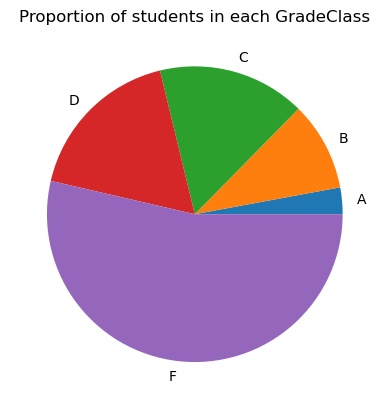

In [34]:
plt.title("Proportion of students in each GradeClass")
plt.pie(groupbyClass['Count'], labels = groupbyClass['GradeClass'])
plt.show()

According to the index, we can see which is grade A, B, C, D, F if we map back to the table. Based on my observations, it is obvious that the largest proportion of students has Grade F as more than half of the pie chart belongs to grade class F and the smallest propertion of students has Grade A. I can say that the distribution of the students is more towards the lower grade side, concluding that it is skewed towards the lower grades side, which tells me that majority of the students did not receive good grades. The mode is clearly GradeClass F, the mean and median is estimated to be on the lower side as majority of the students got low grades but we can't know for sure as we do not have the specific percentages.

### 3. Challenge: show the slice percentages on the pie chart and compare with the percentages you calculated in A2.1.

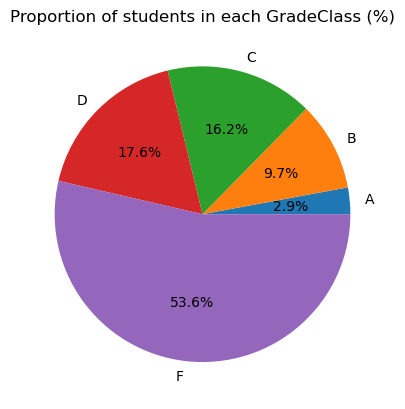

In [35]:
plt.title("Proportion of students in each GradeClass (%)")
plt.pie(groupbyClass['Count'], labels = groupbyClass['GradeClass'], autopct = '%1.1f%%')
plt.show()

#Used auto pct to get the percentage. This is actually shown in the page 3 of the assignment pdf by the way.

- The percentages from A2.1 are 
A	2.907531%
B	9.723546%
C	16.158246%
D	17.588179%
F	53.622498%

- in the pie chart above is:
A	2.9%
B	9.7%
C	16.2%
D	17.6%
F	53.6%

- So the percentages from A2.1 are more detailed and precised compared to the percentages in the pie chart above. This is because the percentage values from A2.1 are not rounded up unlike the percentages in the pie chart above. For instance, the percentages calculated in A2.1 for Grade C is 16.158246%, but in the pie chart above it rounded up to 16.2%, making it less accurate. I see this happen for Grade D as well, where in A2.1 it's 17.588179% but in the pie chart above it's 17.6%. Although the values slightly differ, it is not accurate as 16.158246% != 16.2%.

### 4. Create appropriate visualisations (e.g., scatter plots, histograms, etc) to investigate the relationship between weekly study time and GPA. Calculate and interpret their correlation.

## GRAPH 1

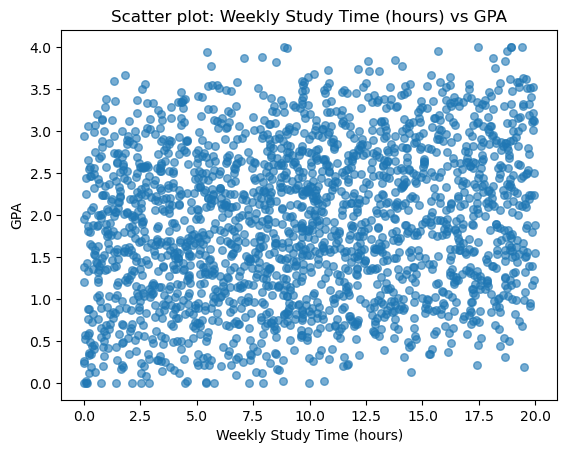

In [36]:
plt.scatter(x= student_list['StudyTimeWeekly'], y=student_list['GPA'],alpha = 0.60, s=30)
plt.xlabel("Weekly Study Time (hours)")
plt.ylabel("GPA")
plt.title("Scatter plot: Weekly Study Time (hours) vs GPA")
plt.show()

## GRAPH 2

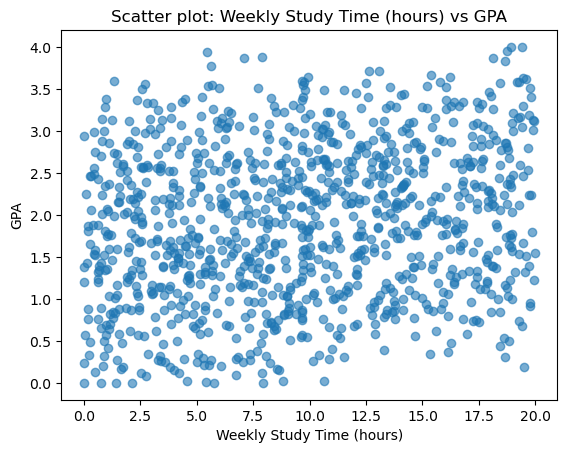

In [37]:
half_data = len(student_list)//2
first_half = student_list.iloc[:half_data]
second_half = student_list.iloc[half_data:]

plt.scatter(x= first_half['StudyTimeWeekly'], y=first_half['GPA'], alpha = 0.6)
plt.xlabel("Weekly Study Time (hours)")
plt.ylabel("GPA")
plt.title("Scatter plot: Weekly Study Time (hours) vs GPA")
plt.show()

## GRAPH 3

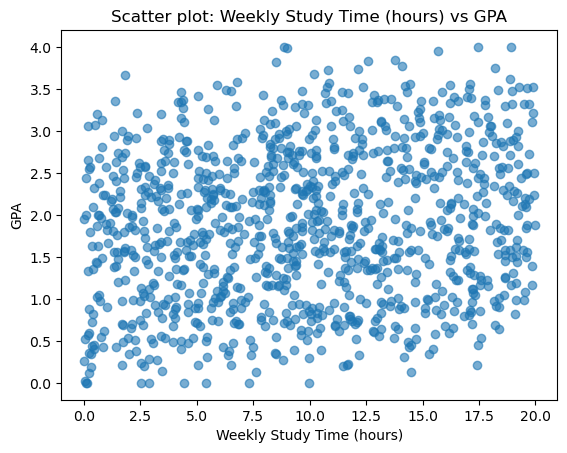

In [38]:
plt.scatter(x=second_half['StudyTimeWeekly'], y=second_half['GPA'], alpha = 0.6)
plt.xlabel("Weekly Study Time (hours)")
plt.ylabel("GPA")
plt.title("Scatter plot: Weekly Study Time (hours) vs GPA")
plt.show()

## GRAPH 4

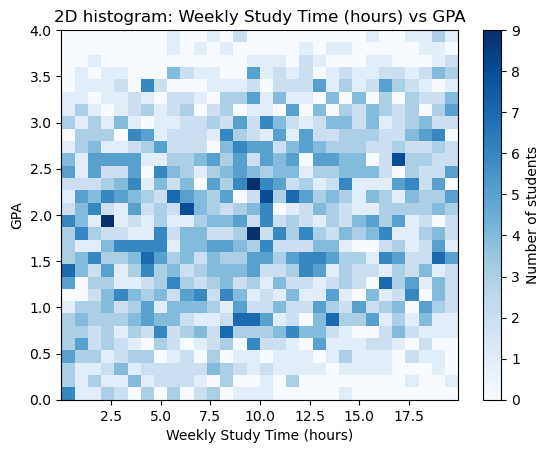

In [39]:
plt.hist2d(x= student_list["StudyTimeWeekly"], y=student_list['GPA'], bins = (30,30), cmap = "Blues")
plt.xlabel("Weekly Study Time (hours)")
plt.ylabel("GPA")
plt.title("2D histogram: Weekly Study Time (hours) vs GPA")
plt.colorbar(label = "Number of students")
plt.show()

In [40]:
corr = student_list['StudyTimeWeekly'].corr(student_list['GPA'])
corr

np.float64(0.17909801846568923)

## Graph 5

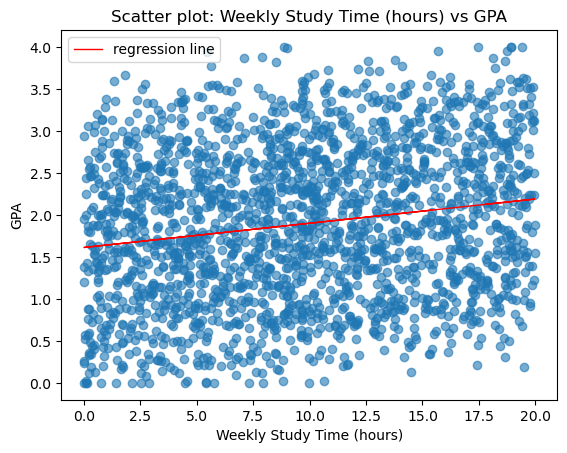

In [41]:
import numpy as np

x = np.array(student_list['StudyTimeWeekly'])
y = np.array(student_list['GPA'])
x_mean = np.mean(x)
y_mean = np.mean(y)
slope = np.sum((x - x_mean)*(y - y_mean))/ np.sum((x - x_mean) ** 2)
intercept = y_mean - slope*x_mean
y_pred = slope * x + intercept 
plt.scatter(x, y, alpha = 0.6)
plt.plot(x, y_pred, color = "red", linewidth = 1 , label="regression line")
plt.xlabel("Weekly Study Time (hours)")
plt.ylabel("GPA")
plt.title("Scatter plot: Weekly Study Time (hours) vs GPA")
plt.legend()

- Graph 1 = scatter plot of entire data
- Graph 2 = scatter plot of first half data
- Graph 3 = scatter plot of second half data
- Graph 4 = hex plot of the entire data
- Graph 5 = scatter plot of the entire data with regression line
- Correlation between weekly study time and GPA = 0.17909801846568923

From graph 1 and 4 we see that the data is slightly concentrated at lower weekly study time and there is data spread throughout the hours as well, but we can see that the plots of GPA varies even at the longer hour range so it's hard to visualize a trend as the pattern is not obvious. We see in Graph 4 specifcally where there it is more concentrated in the lower range of weekly study hours and there are 3 concentrated spots mostly in range 1.5 to 2.5 GPA, which tells me that majority of the students resides in this range. I split the data set into half to have a better visualization to confirm my analysis, take a look at graph 2 and 3 which we can see the same pattern where the the plots are more concentrated at the lower study hours, and their GPA varies. From graph 5, I plotted the regression line across graph 1 to see the slope to determine the relationship between GPA and Weekly Study Time. This tells me that students that study more tend to have higher GPAs.

Finally, I proceeded to calculate the correlation which is 0.17909801846568923, falling under the range of r = 0.1 - 0.5 which signifies there is weak to moderate correlation between StudyTimeWeekly and GPA. This indicates that there is some evidence where the hours of study time weekly correlates to GPA but the relationship is very weak as show in graph 5 with the regression line.

### 5. Identify another feature (other than GradeClass) that has either a positive or negative correlation with GPA. Provide a plot and explain this relationship in terms of student behaviour in this dataset, not just a statistical value.

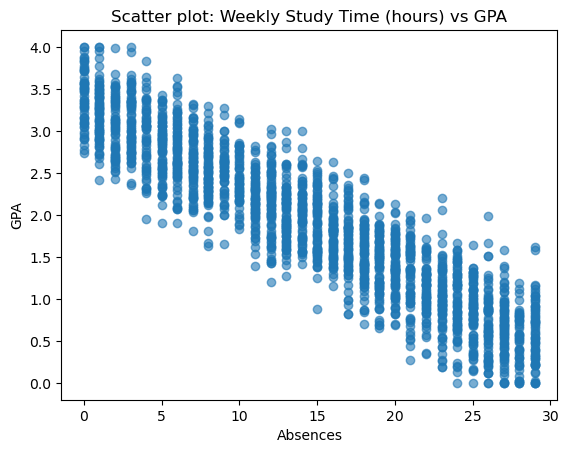

In [42]:
plt.scatter(x= student_list['Absences'], y=student_list['GPA'], alpha = 0.60)
plt.xlabel("Absences")
plt.ylabel("GPA")
plt.title("Scatter plot: Weekly Study Time (hours) vs GPA")
plt.show()

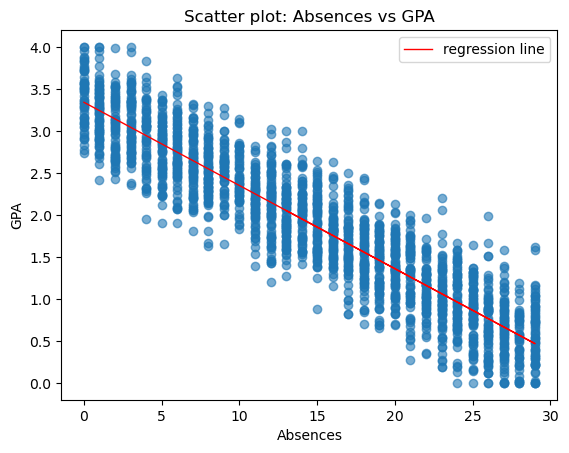

In [43]:
x = np.array(student_list['Absences'])
y = np.array(student_list['GPA'])
x_mean = np.mean(x)
y_mean = np.mean(y)
slope = np.sum((x - x_mean)*(y - y_mean))/ np.sum((x - x_mean) ** 2)
intercept = y_mean - slope*x_mean
y_pred = slope * x + intercept 
plt.scatter(x, y, alpha=0.6)
plt.plot(x, y_pred, color = "red", linewidth = 1 , label="regression line")
plt.xlabel("Absences")
plt.ylabel("GPA")
plt.title("Scatter plot: Absences vs GPA")
plt.legend()

In [44]:
corr2 = student_list['GPA'].corr(student_list['Absences'])
corr2

np.float64(-0.9197788569386005)

From the graph I can see that there is a downwards slope pattern whereby the lesser the absences, the higher the GPA ; the more the absences, the lower the GPA. I plotted the regression line on the graph and I see the same exact pattern where the line is drastically slanted downwards. This might be because if the student are absent most of the time, they wont grasp the knowledge of the teaching materials, hence they struggle to excel during exams, causing their GPA to drop. To confirm my assumption, we calculate the correlation between GPA and absences which is -0.9197788569386005, meaning there is a strong negative correlation between the two variables which proves our assumption to be true. 

### 6. Critically discuss whether correlation alone is sufficient to conclude causation in this dataset. Propose additional data that would help strengthen your argument.

Correlation alone is not sufficient to conclude causation in this dataset because correlation only measures the strength between the GPA and Absences, but it is not a precise tool to determine the underlying cause of the correlation as the causation could be of many different reasons. For example, the reason for a low GPA might be due to the student anable to keep up with the content of the classes hence they skip the class or someone who might not have daily access to come to class wll skip class and hence the GPA drops. It is not solely because of their absences that caused the GPA to drop. To strengthen my argument, I think collecting surveys from the students directly on the causations of their absences are much more accurate as we are retrieving the data directly from the source itself. Another option is to host an experiment where if we implement factors that achieve the reduction of absences and analyse if the GPA changes.

### 7. Group the dataset by ‘GradeClass’ and, in a single .agg() call on GPA and Absences, compute the following:
- mean, median, std (built-ins) and
- IQR via lambda.

In [45]:
table = student_list.groupby("GradeClass").agg({"GPA" :["mean", "median", "std", lambda x: x.quantile(0.75) - x.quantile(0.25)], "Absences" : ["mean", "median", "std", lambda x: x.quantile(0.75) - x.quantile(0.25)]})

In [46]:
table

GPA                                  Absences         \
                mean    median       std <lambda_0>       mean median   
GradeClass                                                              
A           3.681490  3.618273  0.163589   0.275281   1.475410    1.0   
B           3.227285  3.219432  0.143109   0.242832   3.308824    3.0   
C           2.732964  2.723828  0.145818   0.250655   6.433628    6.0   
D           2.249837  2.240924  0.137388   0.230745  11.140921   11.0   
F           1.181513  1.234141  0.513394   0.788061  21.008000   21.0   

                                 
                 std <lambda_0>  
GradeClass                       
A           1.659383        3.0  
B           2.500782        4.0  
C           3.562318        5.0  
D           3.783787        6.0  
F           5.033246        8.0

In [47]:
table = table.rename(columns={"<lambda_0>" : "IQR"})

In [48]:
table

GPA                                 Absences         \
                mean    median       std       IQR       mean median   
GradeClass                                                             
A           3.681490  3.618273  0.163589  0.275281   1.475410    1.0   
B           3.227285  3.219432  0.143109  0.242832   3.308824    3.0   
C           2.732964  2.723828  0.145818  0.250655   6.433628    6.0   
D           2.249837  2.240924  0.137388  0.230745  11.140921   11.0   
F           1.181513  1.234141  0.513394  0.788061  21.008000   21.0   

                           
                 std  IQR  
GradeClass                 
A           1.659383  3.0  
B           2.500782  4.0  
C           3.562318  5.0  
D           3.783787  6.0  
F           5.033246  8.0

In [49]:
table.reset_index()

GradeClass       GPA                                 Absences         \
                  mean    median       std       IQR       mean median   
0          A  3.681490  3.618273  0.163589  0.275281   1.475410    1.0   
1          B  3.227285  3.219432  0.143109  0.242832   3.308824    3.0   
2          C  2.732964  2.723828  0.145818  0.250655   6.433628    6.0   
3          D  2.249837  2.240924  0.137388  0.230745  11.140921   11.0   
4          F  1.181513  1.234141  0.513394  0.788061  21.008000   21.0   

                  
        std  IQR  
0  1.659383  3.0  
1  2.500782  4.0  
2  3.562318  5.0  
3  3.783787  6.0  
4  5.033246  8.0

clean version of the mean, median, std and IQR of both GPA and Absences provided above.

### 8. Challenge: The resulting DataFrame will have MultiIndex columns (two levels: variable name and statistic). Tidy up the DataFrame so that the columns have single-level names. When renaming, make sure that the new column names clearly distinguish between GPA statistics and Absences statistics (e.g., GPA_mean, Absences_mean, etc.).

In [50]:
table.columns = [f"{col[0]}_{col[1]}" for col in table.columns]
#directly rename according to the top column for the GPA/Absences and the second top column for the context.

In [51]:
table.reset_index()

,GradeClass,GPA_mean,GPA_median,GPA_std,GPA_IQR,Absences_mean,Absences_median,Absences_std,Absences_IQR
0,A,3.681490,3.618273,0.163589,0.275281,1.475410,1.0,1.659383,3.0
1,B,3.227285,3.219432,0.143109,0.242832,3.308824,3.0,2.500782,4.0
2,C,2.732964,2.723828,0.145818,0.250655,6.433628,6.0,3.562318,5.0
3,D,2.249837,2.240924,0.137388,0.230745,11.140921,11.0,3.783787,6.0
4,F,1.181513,1.234141,0.513394,0.788061,21.008000,21.0,5.033246,8.0


## *A3. Supervised Learning (3marks)*

### 1. Explain supervised ML using ‘GradeClass’ as the label. Define training vs testing in your own words and give one risk of not holding out a test set.

Supervised ML is when we know what we have a labeled datasets to train algorithms based on patterns in data so that it can map input data to its rightful output/known output label. So for example in our dataset, the 'GradeClass' is the label which consists of {A,B,C,D,F} and we train the model by letting it learn the mapping between the inputs and the label which we discussed earlier, if we have more absences, this often leads to lower GradeClass/GPA.

Training is a dataset where we feed this training dataset to the machine to learn. Testing is another dataset which the model completely has not seen during the training. For example, we have our full dataset (100%), we split the data to two parts, 70% and 30% in which we feed the 70% to the machine and 30% we use the data for testing. One risk of not implementing a test set is without testing the model, we cannot outright confirm that the model is actually working or straight memorizing input to output so if we run a somewhat similar testing data on the machine, it is unable to map the output as it has not seen it before as it just blindly memorizes the exact specific input to the exact specific output.

### 2. Use the wrangled data from A1 and separate the features from the label. The label is ‘GradeClass’. For each column in the dataset, decide whether to keep it as a feature or exclude it, and briefly justify your choice. In your reasoning, consider whether the column:
- is an identifier,
- overlaps with the label, or
- provides useful information for predicting ‘GradeClass’.
Your final selected features will be used to answer the remaining
questions.

In [52]:
student_list

,StudentID,Age,StudyTimeWeekly,Absences,ParentalSupport,GPA,GradeClass
1,1002,18,15.408756,0,1,3.042915,B
2,1003,15,4.210570,26,2,0.112602,F
3,1004,17,10.028829,14,3,2.054218,D
4,1005,17,4.672495,17,3,1.288061,F
5,1006,18,8.191219,0,1,3.084184,B
...,...,...,...,...,...,...,...
2094,3386,16,1.445434,20,3,1.395631,F
2095,3388,18,10.680555,2,4,3.455509,B
2096,3390,16,6.805500,20,2,1.142333,F
2097,3391,16,12.416653,17,2,1.803297,F


**Total columns are StudentID, Age, StudyTimeWeekly, Absences, ParentalSupport, GPA, GradeClass**
### Student ID :
- is an identifier = yes
- overlaps with the label = no
- provides useful information for predicting 'GradeClass' = no
  
### Age :
- is an identifier = no
- overlaps with the label = no
- provides useful information for predicting 'GradeClass' = yes

### StudyTimeWeekly :
- is an identifier = no
- overlaps with the label = no
- provides useful information for predicting 'GradeClass' = yes

### Absences :
- is an identifier = no
- overlaps with the label = no
- provides useful information for predicting 'GradeClass' = yes

### Parental Support :
- is an identifier = no
- overlaps with the label = no
- provides useful information for predicting 'GradeClass' = yes

### GPA :
- is an identifier = no
- overlaps with the label = yes
- provides useful information for predicting 'GradeClass' = no

### Grade Class :
- is an identifier = no
- overlaps with the label = is a label
- provides useful information for predicting 'GradeClass' = no

I've decided to keep all EXCEPT the StudentID, GPA and GradeClass. This is because the StudentID is just a unique identifier to each student, and the GPA overlaps with the label. I've decided to keep Age because it is an important factor that affects behaviour, study habits and learning ability; StudyTimeWeekly because if a student studies longer hours in a week, it will often affect the grades positively ; Absences because as discussed earlier, there is a strong negative correlation with the GPA/GradeClass, students that are often absence tend to have lower grades ; ParentalSupport because it can be one of the underlying causes as to why student grades are dropping, for example if the student doesn't receive parental support and grows up in a abusive household, this might demotivate the student, affecting the learning capabilities due to mental trauma and causing a lower grade ; GradeClass because this is the label and this is what we want to predict so we cannot include it in the inputs.

### 3. Use the sklearn.model_selection.train_test_split function to split your data for training and testing (Keep 70% of the data for training). Report the number of samples in each set after the split. If you had a very small dataset, would you still use 70/30? Justify your answer.

In [53]:
from sklearn.model_selection import train_test_split

In [54]:
X = student_list[["Age", "StudyTimeWeekly", "Absences", "ParentalSupport"]]
y = student_list['GradeClass']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.3, random_state = 0)

In [55]:
X_train.shape

(1468, 4)

In [56]:
X_test.shape

(630, 4)

From this we know that the training dataset has 1468 samples and the test dataset has 630 samples. If I had a very small dataset, I would not use 70/30 because the training set will be really small hence the model may not be able to learn or pick up patterns efficiently. This might heavily jeopordize the testing part, and since we don't have alot of tests to test the model, this might increase the risk of it failing new or unseen data in the future, making the model to be less reliable as a whole.

## A4. Classification (training) (5marks)

### **1. In preparation for classification, your data should be normalised/scaled.**

### a. In your own words, explain why normalisation is necessary, and use one concrete feature pair from your dataset (e.g., Age vs Absences) to show what would happen if you did not scale them. Relate your answer to what was discussed in your Week 7 applied session.

Normalisation is necessary because without feature scaling, the objective functions of the model may not work properly due to the range of values of raw data varies widely. Say we didn't scale, then each feature would not contribute approximately proportionately to the final distance. For example if we have Age vs Absences:

In [57]:
from sklearn.preprocessing import StandardScaler

#take the first two rows
X = student_list[['Age','Absences']].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

row1 = X[0]
row2 = X[1]

row_1_scaled = X_scaled[0]
row_2_scaled = X_scaled[1]

e_dist = np.linalg.norm(row1 - row2)
e_dist_scaled = np.linalg.norm(row_1_scaled - row_2_scaled)

In [58]:
e_dist

np.float64(26.1725046566048)

In [59]:
e_dist_scaled

np.float64(4.07702072198703)

I clearly see that there is a huge difference in the distance between scaling and non scaling values of the euclidean distance. The raw distance calculate is 26.1725046566048 wheareas the scaled value is 4.07702072198703. The non scaled distance is large because the absences differences overpowers the age because the absences has a much larger calculated numeric range compared to age, which might make the model think that absences are more important than age in deciding factors. If we scale it, we make the age equally as important as the absences, so both the age and absences will affect the classification equally.

### b. Choose and use the appropriate normalisation functions available in sklearn.preprocessing and scale the data appropriately. State exactly which columns were scaled

In [60]:
student_list.head()

,StudentID,Age,StudyTimeWeekly,Absences,ParentalSupport,GPA,GradeClass
1,1002,18,15.408756,0,1,3.042915,B
2,1003,15,4.210570,26,2,0.112602,F
3,1004,17,10.028829,14,3,2.054218,D
4,1005,17,4.672495,17,3,1.288061,F
5,1006,18,8.191219,0,1,3.084184,B


In [61]:
scale_columns = ['Age','StudyTimeWeekly', 'Absences','ParentalSupport']
scaler = StandardScaler()
X_train[scale_columns] = scaler.fit_transform(X_train[scale_columns])
X_test[scale_columns] = scaler.transform(X_test[scale_columns])

I used the standard scaler to scale the data in the columns : 'Age','StudyTimeWeekly', 'Absences','ParentalSupport'. 

### **2. Use the Support Vector Machine algorithm to build the model.**

### a. Describe SVM. Again, this is not in your lecture content, you need to do some self-learning.

A support vector machine is a supervised machine learning algorithm used for classification and regression functions. It is a tool used in finding the best boundary called a hyperplane that divides data into different classes, acting as a decision boundary tool. The data points that are closest to the hyperplane are called support vectors which helps in the decision boundary making.

### b. In SVM, there is something called the kernel. Explain what you understand from it.

The kernel is a mathematical function used in SVM that finds non-linear decision boundaries by mapping the data into a higher dimensional space where it is easier to seperate the classes. In simpler terms, the kernel allows the support vector machine to bend the space so that it can seperate complicated data. For example, if I have different groups of students which studies:
Group A students = Chemistry
Group B students = Biology
Group C students = Both 
If I were to plot this in a 2D graph, the data for Group C students will be in between the middle of Group A and B so it would be impossible to seperate them efficiently with a straight line. So that's where the kernel comes into play, it projects the data into a higher dimension where Group C data gets lifted out (like adding a height dimension), then I can now seperate all groups with a clear boundary.

### c. Write the code to build a predictive SVM model using your training dataset. (Note: You are allowed to engineer or remove features as you deem appropriate)

In [62]:
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

X = student_list[["Age","StudyTimeWeekly", "Absences", "ParentalSupport"]]
y = student_list['GradeClass']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.3, random_state = 0)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

svm_model = SVC(kernel="rbf",class_weight ="balanced", C=1 , random_state = 0)
svm_model.fit(X_train, y_train)

y_pred = svm_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

In [63]:
cm #analyse how many samples are correctly or incorrectly labelled.

array([[ 16,   5,   0,   0,   0],
       [ 22,  27,  18,   2,   0],
       [  3,  20,  48,  25,   0],
       [  0,   0,  22,  87,   7],
       [  0,   0,   0,  46, 282]])

16 students correctly predicted in A, 5 students wrongly predicted in B, none were predicted wrongly in C, D or F.
27 students correctly predicted in B, 22 students wrongly predicted in A, 18 students wrongly predicted in C, 2 in D, none in F.

small analysis: 
F has the best performance, predicting 282 students correctly, so I can say its good at predicting failing students.
but going "up" the grades the model starts to get worse, predicting wrongly for alot of cases such as False Negatives in B and D for Grade C.

In [64]:
output = classification_report(y_test, y_pred, output_dict = True)
report = pd.DataFrame(output).transpose()
report

,precision,recall,f1-score,support
A,0.390244,0.761905,0.516129,21.000000
B,0.519231,0.391304,0.446281,69.000000
C,0.545455,0.500000,0.521739,96.000000
D,0.543750,0.750000,0.630435,116.000000
F,0.975779,0.859756,0.914100,328.000000
accuracy,0.730159,0.730159,0.730159,0.730159
macro avg,0.594892,0.652593,0.605737,630.000000
weighted avg,0.761137,0.730159,0.737578,630.000000


**Precision** = out of all predictions how many are actually correct

**recall** = out of all actual positives, how many were correctly identified

**f1-score** = balance between both precision and recall

**support** = number of true instances for each class 

**macro avg** = simple average of scores across all classes (treats all classes equally)

**accuracy** = overall proportions of correct predictions 

**weighted avg** = average scores weighted by support (takes account class imbalance)

**useful source** : https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html

overall performance accuracy is 0.730159 / 73%

### 3. Train at least one other classifier (e.g., Decision Tree, Random Forest) instead of SVM. You are encouraged to explore other classification algorithms beyond what you have been taught to learn an accurate classifier.

**Decision Tree**

In [65]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(criterion = 'entropy', random_state=0)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

confusion_matrix(y_test,y_pred_dt)

array([[ 10,   9,   2,   0,   0],
       [  8,  26,  28,   7,   0],
       [  4,  18,  43,  29,   2],
       [  0,   2,  22,  56,  36],
       [  0,   0,   2,  30, 296]])

Predicted correctly:
A = 10
B = 26
C = 43
D = 56
F = 296

In [66]:
output2 = classification_report(y_test, y_pred_dt, output_dict = True)
report2 = pd.DataFrame(output2).transpose()
report2

,precision,recall,f1-score,support
A,0.454545,0.476190,0.465116,21.000000
B,0.472727,0.376812,0.419355,69.000000
C,0.443299,0.447917,0.445596,96.000000
D,0.459016,0.482759,0.470588,116.000000
F,0.886228,0.902439,0.894260,328.000000
accuracy,0.684127,0.684127,0.684127,0.684127
macro avg,0.543163,0.537223,0.538983,630.000000
weighted avg,0.680395,0.684127,0.681564,630.000000


overall performance accuracy is 0.684127 / 68%

**Random Forest**

In [67]:
from sklearn.ensemble import RandomForestClassifier

forest = RandomForestClassifier(n_estimators = 100, criterion = "gini", max_depth = 12, 
                                min_samples_split=4, min_samples_leaf = 2, class_weight = "balanced", random_state = 0)
forest.fit(X_train, y_train)
y_pred_forest = forest.predict(X_test)

confusion_matrix(y_test,y_pred_forest)

array([[  9,  12,   0,   0,   0],
       [ 11,  27,  30,   1,   0],
       [  1,  18,  54,  21,   2],
       [  0,   1,  23,  74,  18],
       [  0,   0,   2,  29, 297]])

Predicted correctly:
A = 9
B = 27
C = 54
D = 74
F = 297

helpful source: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

In [68]:
output3 = classification_report(y_test, y_pred_forest, output_dict = True)
report3 = pd.DataFrame(output3).transpose()
report3

,precision,recall,f1-score,support
A,0.428571,0.428571,0.428571,21.000000
B,0.465517,0.391304,0.425197,69.000000
C,0.495413,0.562500,0.526829,96.000000
D,0.592000,0.637931,0.614108,116.000000
F,0.936909,0.905488,0.920930,328.000000
accuracy,0.731746,0.731746,0.731746,0.731746
macro avg,0.583682,0.585159,0.583127,630.000000
weighted avg,0.737553,0.731746,0.733676,630.000000


the overall performance accuracy for this model is 0.731746.

## **A5. Classification (prediction) (5marks)**

### 1. Using the testing dataset you created in Task A3 above, conduct the prediction for the ‘GradeClass’ (label) using the two models built by SVM and your other classification algorithm.

### SVM

In [69]:
report

,precision,recall,f1-score,support
A,0.390244,0.761905,0.516129,21.000000
B,0.519231,0.391304,0.446281,69.000000
C,0.545455,0.500000,0.521739,96.000000
D,0.543750,0.750000,0.630435,116.000000
F,0.975779,0.859756,0.914100,328.000000
accuracy,0.730159,0.730159,0.730159,0.730159
macro avg,0.594892,0.652593,0.605737,630.000000
weighted avg,0.761137,0.730159,0.737578,630.000000


### Decision Tree

In [70]:
report2

,precision,recall,f1-score,support
A,0.454545,0.476190,0.465116,21.000000
B,0.472727,0.376812,0.419355,69.000000
C,0.443299,0.447917,0.445596,96.000000
D,0.459016,0.482759,0.470588,116.000000
F,0.886228,0.902439,0.894260,328.000000
accuracy,0.684127,0.684127,0.684127,0.684127
macro avg,0.543163,0.537223,0.538983,630.000000
weighted avg,0.680395,0.684127,0.681564,630.000000


### Random Forest

In [71]:
report3

,precision,recall,f1-score,support
A,0.428571,0.428571,0.428571,21.000000
B,0.465517,0.391304,0.425197,69.000000
C,0.495413,0.562500,0.526829,96.000000
D,0.592000,0.637931,0.614108,116.000000
F,0.936909,0.905488,0.920930,328.000000
accuracy,0.731746,0.731746,0.731746,0.731746
macro avg,0.583682,0.585159,0.583127,630.000000
weighted avg,0.737553,0.731746,0.733676,630.000000


There are 3 tables above, but I shall focus on report and report2. The analysed accuracy for SVM (73%) is higher than decision tree (68%), meaning the SVM model is more reliable compared to the decision tree. SVM is much better for identifying Grade A, B, C, D students but Decision Tree algorithm is better at identifying Grade F students, as seen above in both reports under the precision column.

### 2. Display the confusion matrices for both models (it should look like a 5x5 matrix). Unlike the lectures, where it is just a 2x2, you are now introduced to a multi-class classification problem setting. Pick one frequent confusion (e.g., B↔C) and explain why it might occur, e.g., what patterns in features could cause misclassification.

**SVM model**

In [72]:
confusion_matrix(y_test,y_pred_dt)

array([[ 10,   9,   2,   0,   0],
       [  8,  26,  28,   7,   0],
       [  4,  18,  43,  29,   2],
       [  0,   2,  22,  56,  36],
       [  0,   0,   2,  30, 296]])

**Decision Tree model**

In [73]:
confusion_matrix(y_test,y_pred_forest)

array([[  9,  12,   0,   0,   0],
       [ 11,  27,  30,   1,   0],
       [  1,  18,  54,  21,   2],
       [  0,   1,  23,  74,  18],
       [  0,   0,   2,  29, 297]])

The most frequent confusion is B↔C. In the decision tree CM, for B, there are 33 true positives, 27 false negatives, misclassified as C ; for C, there are 52 true positives, but 19 false negatives for B. This tells me that the classifier has issues identifying B and C apart from each other. 

This might happen because the decision boundaries might not be clear for B and C as they might share similar range of grades or performance features, making the the difference in both B and C students hard to distinguish, leading to a the data being swapped often between B class and C class. Additionally, the decision tree might tend to overfit or underfit certain branches, meaning it the criterias to identify which class the data belongs to might be too broad or too specific. And entropy criterion might be one of the causes as well because it if cant clearly identify if its B or C, it will just mix the two classes in the same branch. 

The features that can cause misclassification could most likely be GPA or attendance. For example if a B student and C student might have similar GPA and similar attendance rate, the decision tree can't clearly seperate them, hence the false positives and false negatives between B and C.

### 3. Compare the performance of SVM and your other classifier and provide your justification on which one performed better.

Out of all the classifiers, I will be primarily focusing on the Random Forest classfier and SVM.

In [74]:
report #svm

,precision,recall,f1-score,support
A,0.390244,0.761905,0.516129,21.000000
B,0.519231,0.391304,0.446281,69.000000
C,0.545455,0.500000,0.521739,96.000000
D,0.543750,0.750000,0.630435,116.000000
F,0.975779,0.859756,0.914100,328.000000
accuracy,0.730159,0.730159,0.730159,0.730159
macro avg,0.594892,0.652593,0.605737,630.000000
weighted avg,0.761137,0.730159,0.737578,630.000000


In [75]:
report3 #rf

,precision,recall,f1-score,support
A,0.428571,0.428571,0.428571,21.000000
B,0.465517,0.391304,0.425197,69.000000
C,0.495413,0.562500,0.526829,96.000000
D,0.592000,0.637931,0.614108,116.000000
F,0.936909,0.905488,0.920930,328.000000
accuracy,0.731746,0.731746,0.731746,0.731746
macro avg,0.583682,0.585159,0.583127,630.000000
weighted avg,0.737553,0.731746,0.733676,630.000000


Based on both reports above, I see that the accuracy for the Random Forest classifier is higher than the accuracy for the SVM (73.1746% > 73.0159%), but the SVM is better than the Random Forest classifier in the macro avg and weighted avg (0.605737>0.583127) and (0.737578>0.733676).

This means that SVM balances better across all classes, whereas random forest favours grade F more (the majority class).

I also see that SVM is better in precision (weighted avg of precision: 0.761137 > 0.737553) but random forest has lesser missed predictions overall (weighted avg of recall : 0.731746 > 0.730159), which means random forest captures more of the true positive cases but sacrifices precision and the SVM has fewer false positives but slightly more false negatives.

Both models has weaknesses surrounding the classification of B and C grades, the reason as discussed above. Random Forest classifier is more precise at detecting Grade C (0.526829 > 0.521739), Grade F (0.920930 > 0.914100) but SVM is better at detecting Grade A(0.428571 > 0.428571), Grade B (0.446281 > 0.425197) and Grade D (0.630435 > 0.614108).

From this I can say SVM favours the minority class and Random forest favours the majority class.

I decided that Random Forest performed better because it has better overall accuracy and it is well suited for handling large datasets with non-linear relationships between features, in our case it is StudyTimeWeekly, Absences, Parental Support and the target GradeClass. Additionally, it maintains strong weighted average precision (0.737553) and recall (0.731746) and F1 score (0.7337). The ensemble approach which averages the predictions across multiple trees, reduces overfitting and contributes to a high overall accuracy. Although SVM performed better for minority classes as seen in the individual grades F1 score such as for Grade A and D , the Random Forest is more robust to new or unseen data and provides features importance scaling, and it is more stable and reliable across all grade classes (GeeksforGeeks, n.d.).


reference: https://www.geeksforgeeks.org/machine-learning/when-to-use-random-forest-over-svm-and-vice-versa/

### 4. Challenge (Bias–Variance Reflection): For each classifier you used (SVM and your chosen other classifier), discuss whether the model is more likely to suffer from high bias or high variance on your dataset. Provide reasoning based on the behaviour you observed (e.g., training accuracy vs test accuracy, overfitting/underfitting signs).

In my opinion, the Random Forest tend to have lower bias but higher variance because the individual trees might overfit small patterns because it combines many decision trees. The voting system improves the accuracy for the majority of students which is in Grade F F1 = (0.920930) but the accuracy for the other classes varies such as Grade A F1 = 0.428571 or Grade B F1=0.425197. However, the overall accuracy is 73.1746%, meaning despite overfitting might occur, the ensemble generalizes well. 

The SVM on the other hand, has higher bias and lower variance because it uses the kernel to seperate all the classes, it being a single decision boundary can cause higher bias. Unlike the Random Forest, it performs better for the minority classes. This might mean that it underfits overlapping data boundaries as seen in B and C. It has a lower variance because it is often stable across different datasets as it doesnt change drastically when there is small changes to the dataset like a decision tree. This can be seen from its 73.0159% test accuracy and consistent predictions throughout all the classes even it it underfits the overlapping data. 

All in all, the random forest has lower bias, higher variance ; the SVM has higher bias and lower variance.

## A6. Independent evaluation (Competition) (5 marks)

### 1. Read the Student_List_A2_Submission.csv file and use the best model you built earlier to predict the ‘GradeClass’ for the students in this file. Unlike the previous section in which you have a testing dataset where you know the ‘GradeClass’ and will be able to test for the accuracy, in this file, you don’t have a ‘GradeClass’ and you have to predict it.
#### a. Output of your predictions should be submitted in a CSV file format. It should contain 2 columns: ‘StudentID and ‘GradeClass’. It should have a total of 162 lines (1 header, and 161 entries). And that is considered as your final submission.

### b. Additional step: We have prepared a Kaggle competition platform for you to submit your CSV file and compare your ranking with your classmates. Please use the following naming format:
StudentID-YourName-v1.csv
(e.g., 12345678-JaneDoe-v1.csv)
Note: Only entries submitted using your Monash email account to the Kaggle website will be accepted, and there’s a daily limit of 10 submissions. The Kaggle deadline is different from the assignment deadline, as it is designed to accommodate students with approved extensions (if any).
Link to Kaggle Competition:
https://www.kaggle.com/t/a91974d4aace42008e7431605c058bc2

### c. Hint: you may need to apply some of the data wrangling steps in A1 to this new data file (i.e., Student_List_A2_Submission.csv),to prepare it for prediction.

In [76]:
sl2 = pd.read_csv("Student_List_A2_Submission.csv")

In [77]:
sl2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161 entries, 0 to 160
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   StudentID        161 non-null    int64  
 1   Age              161 non-null    int64  
 2   StudyTimeWeekly  161 non-null    float64
 3   Absences         161 non-null    int64  
 4   ParentalSupport  161 non-null    int64  
dtypes: float64(1), int64(4)
memory usage: 6.4 KB


In [78]:
sl2.describe()

,StudentID,Age,StudyTimeWeekly,Absences,ParentalSupport
count,161.000000,161.000000,161.000000,161.000000,161.000000
mean,5080.000000,16.428571,10.314005,15.217391,2.285714
std,46.620811,1.105183,5.601883,8.367120,1.114835
min,5000.000000,15.000000,0.001057,0.000000,0.000000
25%,5040.000000,15.000000,5.805674,8.000000,2.000000
50%,5080.000000,16.000000,10.437689,15.000000,2.000000
75%,5120.000000,17.000000,14.736337,23.000000,3.000000
max,5160.000000,18.000000,19.198334,29.000000,4.000000


In [79]:
sl2.duplicated().any()

np.False_

In [80]:
sl2.isnull().sum()

StudentID          0
Age                0
StudyTimeWeekly    0
Absences           0
ParentalSupport    0
dtype: int64

In [81]:
sl2.duplicated().sum()

np.int64(0)

In [82]:
import pandas as pd 
import numpy as py
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

In [83]:
forest = RandomForestClassifier(n_estimators = 100, criterion = "gini", max_depth = 12, 
                                min_samples_split=4, min_samples_leaf = 2, class_weight = "balanced", random_state = 0)

X_train = student_list[['StudyTimeWeekly','Absences','ParentalSupport']]
y_train = student_list['GradeClass']

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

forest.fit(X_train_scaled, y_train)

X_new = sl2[['StudyTimeWeekly','Absences','ParentalSupport']]
X_new_scaled = scaler.transform(X_new)
y_new_pred = forest.predict(X_new_scaled)

grade_map = {"A": 0, "B" : 1, "C":2, "D":3, "F":4}
y_new_pred = [grade_map[g] for g in y_new_pred]

output = pd.DataFrame({
    'StudentID': sl2['StudentID'],
    'GradeClass': y_new_pred })

output.to_csv("35172665-HengJunYee-v1.csv", index = False)

# Part B (7 marks): Selection of Dataset and perform Clustering

## B1. Selection of a Dataset with missing data, Clustering

### 1. Select a suitable dataset with empty values

In [84]:
import pandas as pd

In [85]:
bi = pd.read_csv("bi.csv", encoding = 'latin1') 

link to dataset : https://www.kaggle.com/datasets/walekhwatlphilip/intro-to-data-cleaning-eda-and-machine-learning

### 2. Perform wrangling on the dataset to handle/treat the missing data and explain your procedure, including before-and-after evidence.

In [86]:
bi.describe()

,Age,entryEXAM,studyHOURS,Python,DB
count,77.000000,77.000000,77.000000,75.000000,77.000000
mean,35.207792,76.753247,149.714286,75.853333,69.467532
std,10.341966,16.475784,12.743272,15.410328,17.033701
min,21.000000,28.000000,114.000000,15.000000,30.000000
25%,27.000000,69.000000,144.000000,71.000000,56.000000
50%,33.000000,80.000000,156.000000,81.000000,71.000000
75%,42.000000,90.000000,158.000000,85.000000,83.000000
max,71.000000,98.000000,160.000000,91.000000,100.000000


In [87]:
bi.duplicated().any()

np.False_

no duplicates

In [88]:
bi.isna().sum()

fNAME            0
lNAME            0
Age              0
gender           0
country          0
residence        0
entryEXAM        0
prevEducation    0
studyHOURS       0
Python           2
DB               0
dtype: int64

two empty values in python column

In [89]:
bi['Python'] = bi['Python'].fillna(bi['Python'].mean())

In [90]:
bi.isna().sum()

fNAME            0
lNAME            0
Age              0
gender           0
country          0
residence        0
entryEXAM        0
prevEducation    0
studyHOURS       0
Python           0
DB               0
dtype: int64

In [91]:
bi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   fNAME          77 non-null     object 
 1   lNAME          77 non-null     object 
 2   Age            77 non-null     int64  
 3   gender         77 non-null     object 
 4   country        77 non-null     object 
 5   residence      77 non-null     object 
 6   entryEXAM      77 non-null     int64  
 7   prevEducation  77 non-null     object 
 8   studyHOURS     77 non-null     int64  
 9   Python         77 non-null     float64
 10  DB             77 non-null     int64  
dtypes: float64(1), int64(4), object(6)
memory usage: 6.7+ KB


In [92]:
bi.head()

,fNAME,lNAME,Age,gender,country,residence,entryEXAM,prevEducation,studyHOURS,Python,DB
0,Christina,Binger,44,Female,Norway,Private,72,Masters,158,59.000000,55
1,Alex,Walekhwa,60,M,Kenya,Private,79,Diploma,150,60.000000,75
2,Philip,Leo,25,Male,Uganda,Sognsvann,55,HighSchool,130,74.000000,50
3,Shoni,Hlongwane,22,F,Rsa,Sognsvann,40,High School,120,75.853333,44
4,Maria,Kedibone,23,Female,South Africa,Sognsvann,65,High School,122,91.000000,80


In [93]:
bi.tail()

,fNAME,lNAME,Age,gender,country,residence,entryEXAM,prevEducation,studyHOURS,Python,DB
72,Clara,Bernard,43,Female,France,Private,80,Bachelors,150,75.0,43
73,Julian,Nielsen,31,Male,Denmark,Sognsvann,90,Masters,158,84.0,83
74,Sophie,Brown,33,Female,UK,Sognsvann,96,Masters,158,85.0,90
75,Leon,Bauer,35,Male,Germany,Sognsvann,90,Masters,160,87.0,74
76,Mohammed,Salim,31,Male,Somali,Sognsvann,35,Masters,144,72.0,90


data inconsistencies in gender, country , prev education, columns capitalization.

In [94]:
bi.columns = bi.columns.str.strip().str.lower().str.capitalize()

In [95]:
bi

,Fname,Lname,Age,Gender,Country,Residence,Entryexam,Preveducation,Studyhours,Python,Db
0,Christina,Binger,44,Female,Norway,Private,72,Masters,158,59.000000,55
1,Alex,Walekhwa,60,M,Kenya,Private,79,Diploma,150,60.000000,75
2,Philip,Leo,25,Male,Uganda,Sognsvann,55,HighSchool,130,74.000000,50
3,Shoni,Hlongwane,22,F,Rsa,Sognsvann,40,High School,120,75.853333,44
4,Maria,Kedibone,23,Female,South Africa,Sognsvann,65,High School,122,91.000000,80
...,...,...,...,...,...,...,...,...,...,...,...
72,Clara,Bernard,43,Female,France,Private,80,Bachelors,150,75.000000,43
73,Julian,Nielsen,31,Male,Denmark,Sognsvann,90,Masters,158,84.000000,83
74,Sophie,Brown,33,Female,UK,Sognsvann,96,Masters,158,85.000000,90
75,Leon,Bauer,35,Male,Germany,Sognsvann,90,Masters,160,87.000000,74


In [96]:
bi['Gender'] = bi['Gender'].str.strip().str.lower()
bi['Gender'] = bi['Gender'].replace({ 'm' : "male" , "f" : "female"})

In [97]:
bi['Gender'].unique()

array(['female', 'male'], dtype=object)

In [98]:
bi

,Fname,Lname,Age,Gender,Country,Residence,Entryexam,Preveducation,Studyhours,Python,Db
0,Christina,Binger,44,female,Norway,Private,72,Masters,158,59.000000,55
1,Alex,Walekhwa,60,male,Kenya,Private,79,Diploma,150,60.000000,75
2,Philip,Leo,25,male,Uganda,Sognsvann,55,HighSchool,130,74.000000,50
3,Shoni,Hlongwane,22,female,Rsa,Sognsvann,40,High School,120,75.853333,44
4,Maria,Kedibone,23,female,South Africa,Sognsvann,65,High School,122,91.000000,80
...,...,...,...,...,...,...,...,...,...,...,...
72,Clara,Bernard,43,female,France,Private,80,Bachelors,150,75.000000,43
73,Julian,Nielsen,31,male,Denmark,Sognsvann,90,Masters,158,84.000000,83
74,Sophie,Brown,33,female,UK,Sognsvann,96,Masters,158,85.000000,90
75,Leon,Bauer,35,male,Germany,Sognsvann,90,Masters,160,87.000000,74


gender column fixed 

In [99]:
bi["Preveducation"] = bi["Preveducation"].str.strip().str.lower()
bi["Preveducation"] = bi["Preveducation"].replace({ "highschool" : "high school"})

In [100]:
bi

,Fname,Lname,Age,Gender,Country,Residence,Entryexam,Preveducation,Studyhours,Python,Db
0,Christina,Binger,44,female,Norway,Private,72,masters,158,59.000000,55
1,Alex,Walekhwa,60,male,Kenya,Private,79,diploma,150,60.000000,75
2,Philip,Leo,25,male,Uganda,Sognsvann,55,high school,130,74.000000,50
3,Shoni,Hlongwane,22,female,Rsa,Sognsvann,40,high school,120,75.853333,44
4,Maria,Kedibone,23,female,South Africa,Sognsvann,65,high school,122,91.000000,80
...,...,...,...,...,...,...,...,...,...,...,...
72,Clara,Bernard,43,female,France,Private,80,bachelors,150,75.000000,43
73,Julian,Nielsen,31,male,Denmark,Sognsvann,90,masters,158,84.000000,83
74,Sophie,Brown,33,female,UK,Sognsvann,96,masters,158,85.000000,90
75,Leon,Bauer,35,male,Germany,Sognsvann,90,masters,160,87.000000,74


In [101]:
bi["Preveducation"].unique()

array(['masters', 'diploma', 'high school', 'bachelors', 'barrrchelors',
       'diplomaaa', 'doctorate'], dtype=object)

okay so there are still other errors, im gonna change that.

In [102]:
bi["Preveducation"] = bi["Preveducation"].replace({ "diplomaaa" : "diploma"})
bi["Preveducation"] = bi["Preveducation"].replace({ "barrrchelors" : "bachelors"})

In [103]:
bi["Preveducation"].unique()

array(['masters', 'diploma', 'high school', 'bachelors', 'doctorate'],
      dtype=object)

In [104]:
bi['Country'].unique()

array(['Norway', 'Kenya', 'Uganda', 'Rsa', 'South Africa', 'Norge',
       'norway', 'Denmark', 'Netherlands', 'Italy', 'Spain', 'UK',
       'Somali', 'Nigeria', 'Germany', 'France'], dtype=object)

In [105]:
bi["Country"] = bi["Country"].replace({ "norway" : "Norway"})
bi["Country"] = bi["Country"].replace({ "Norge" : "Norway"}) #norge is the swedish name for norway I googled.
bi["Country"] = bi["Country"].replace({ "rsa" : "RSA"})

In [106]:
bi['Country'].unique()

array(['Norway', 'Kenya', 'Uganda', 'Rsa', 'South Africa', 'Denmark',
       'Netherlands', 'Italy', 'Spain', 'UK', 'Somali', 'Nigeria',
       'Germany', 'France'], dtype=object)

In [107]:
bi['Residence'].unique()

array(['Private', 'Sognsvann', 'BI Residence', 'BI-Residence',
       'BIResidence', 'BI_Residence'], dtype=object)

In [108]:
bi["Residence"] = bi["Residence"].replace({ "BI-Residence" : "BI Residence"})
bi["Residence"] = bi["Residence"].replace({ "BIResidence" : "BI Residence"})
bi["Residence"] = bi["Residence"].replace({ "BI_Residence" : "BI Residence"})

In [109]:
bi.describe()

,Age,Entryexam,Studyhours,Python,Db
count,77.000000,77.000000,77.000000,77.000000,77.000000
mean,35.207792,76.753247,149.714286,75.853333,69.467532
std,10.341966,16.475784,12.743272,15.206208,17.033701
min,21.000000,28.000000,114.000000,15.000000,30.000000
25%,27.000000,69.000000,144.000000,72.000000,56.000000
50%,33.000000,80.000000,156.000000,81.000000,71.000000
75%,42.000000,90.000000,158.000000,85.000000,83.000000
max,71.000000,98.000000,160.000000,91.000000,100.000000


### 3. Perform k-means clustering, choosing two numerical features in your dataset and create k clusters using Python (k>=2). Justify your choice of k.

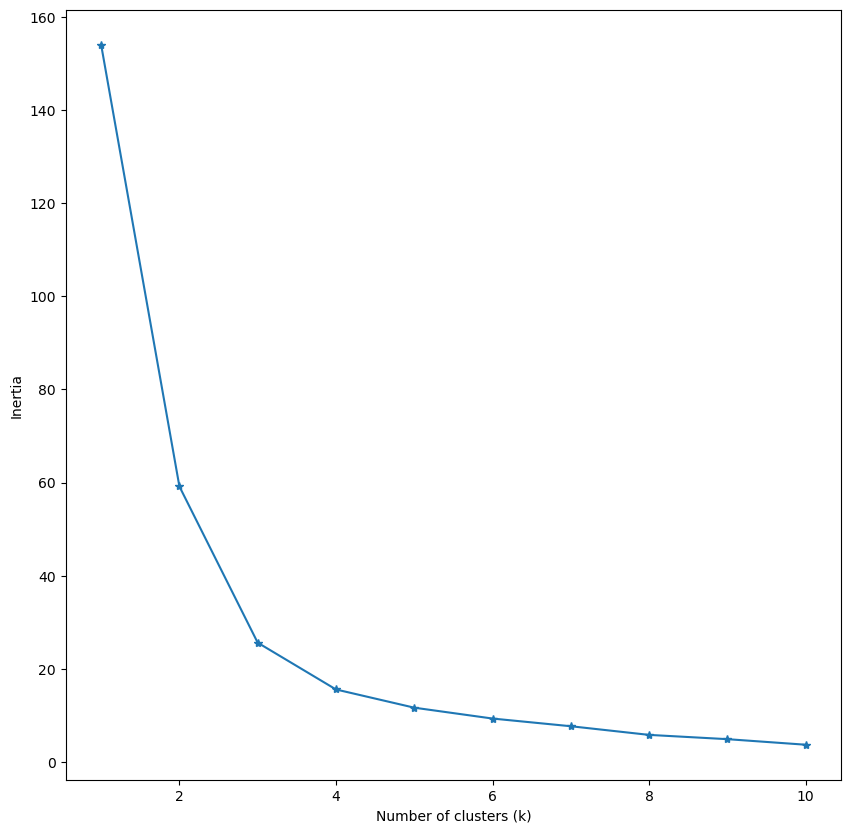

In [110]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

#I choose the numerical feature of age and study hours
X = bi[['Python', 'Studyhours']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#to decide what k value to go for, i will draft a graph to see where the optimal number of clusters should be

inertia = []

for k in range(1,11):
    kmeans = KMeans(n_clusters=k, random_state = 0, n_init = 10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

#plot the graph to visualise 
plt.figure(figsize=(10,10))
plt.plot(range(1,11), inertia, marker = "*")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.show()

helpful reference from = https://www.geeksforgeeks.org/machine-learning/ml-determine-the-optimal-value-of-k-in-k-means-clustering/

I see that the optimal value is 4 as the curve starts to flatten out after 4.  

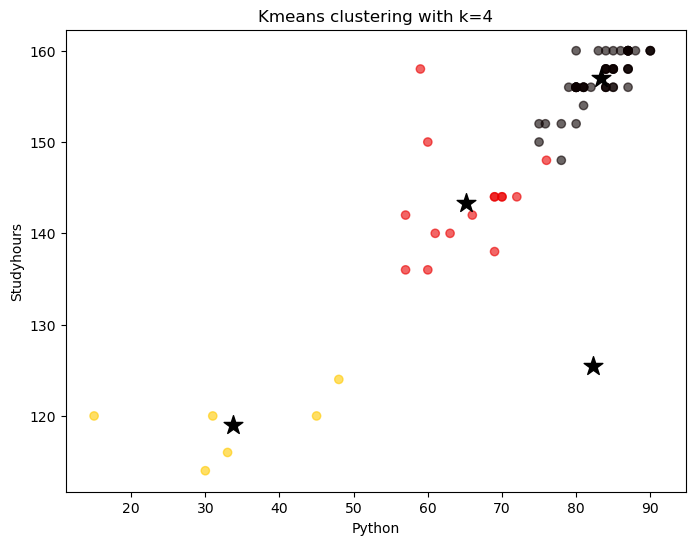

In [111]:
kmeans = KMeans(n_clusters = 4 , random_state = 0 , n_init = 10)
bi['cluster'] = kmeans.fit_predict(X_scaled)

plt.figure(figsize= (8,6))
plt.scatter(X['Python'], X['Studyhours'], c=bi["cluster"], cmap = "hot", alpha = 0.6)

centers = scaler.inverse_transform (kmeans.cluster_centers_)
plt.scatter(centers[:,0], centers[:,1], c= "black", marker="*", s=200 , label = "Centers")

plt.xlabel("Python")
plt.ylabel("Studyhours")
plt.title("Kmeans clustering with k=4")
plt.show()

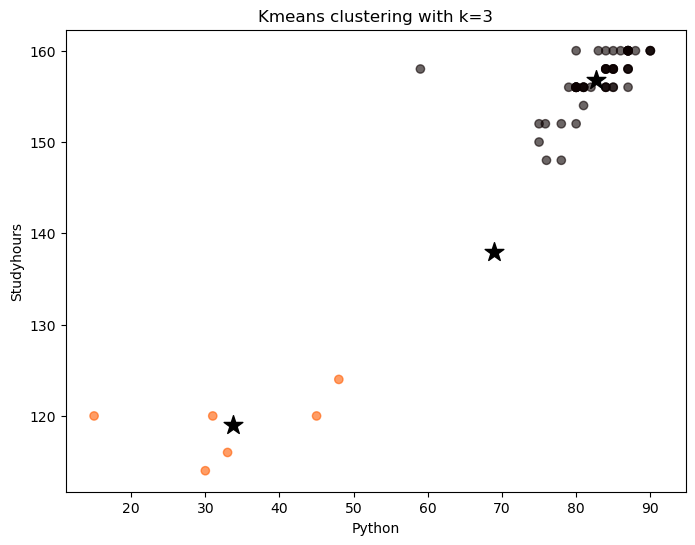

In [112]:
kmeans = KMeans(n_clusters = 3 , random_state = 0 , n_init = 10)
bi['cluster'] = kmeans.fit_predict(X_scaled)

plt.figure(figsize= (8,6))
plt.scatter(X['Python'], X['Studyhours'], c=bi["cluster"], cmap = "hot", alpha = 0.6)

centers = scaler.inverse_transform (kmeans.cluster_centers_)
plt.scatter(centers[:,0], centers[:,1], c= "black", marker="*", s=200 , label = "Centers")

plt.xlabel("Python")
plt.ylabel("Studyhours")
plt.title("Kmeans clustering with k=3")
plt.show()

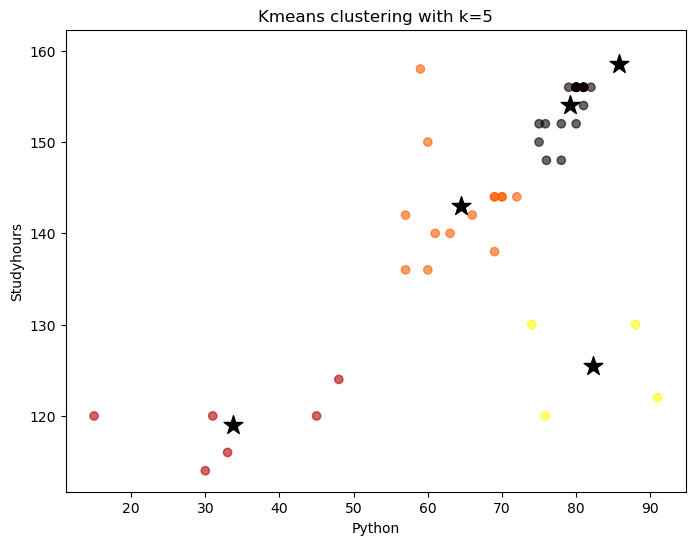

In [113]:
kmeans = KMeans(n_clusters = 5 , random_state = 0 , n_init = 10)
bi['cluster'] = kmeans.fit_predict(X_scaled)

plt.figure(figsize= (8,6))
plt.scatter(X['Python'], X['Studyhours'], c=bi["cluster"], cmap = "hot", alpha = 0.6)

centers = scaler.inverse_transform (kmeans.cluster_centers_)
plt.scatter(centers[:,0], centers[:,1], c= "black", marker="*", s=200 , label = "Centers")

plt.xlabel("Python")
plt.ylabel("Studyhours")
plt.title("Kmeans clustering with k=5")
plt.show()

I have selected to have 4 clusters because in the graph where we plotted the inertia, we see that after 4 the line starts to flatten out, meaning it doesn't effect much on the inertia hence not as efficient. Although there is only one unnecessary cluster, 4 is the most optimal number of clusters because the stars located in the center of the clusters accurately and the number of unnecessary clusters are lesser than using other k values. The k = 2 graph has too few clusters, in which we might group different classes of students together causing oversimplification. The k = 5 graph has too many clusters at the top part as the distance between the two stars are somewhat close with each other, which might split the same classes of student apart, leading to overfitting.

### 4. Visualise both the raw data and the cluster results, with clear labels, titles, and legends.

Text(0.5, 1.0, 'Raw Data (Python vs Studyhours)')

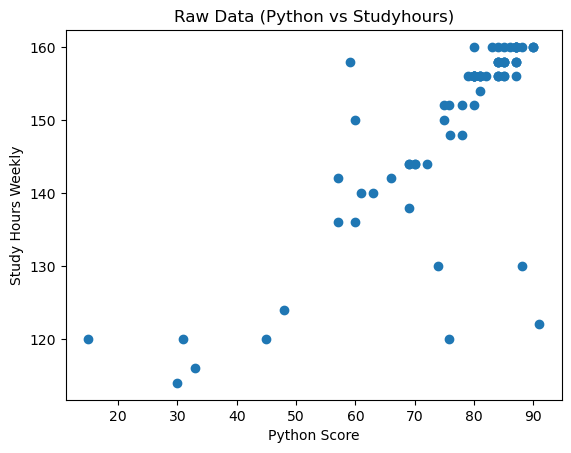

In [114]:
plt.scatter(x=bi['Python'], y=bi['Studyhours'])
plt.xlabel('Python Score')
plt.ylabel('Study Hours Weekly')
plt.title("Raw Data (Python vs Studyhours)")

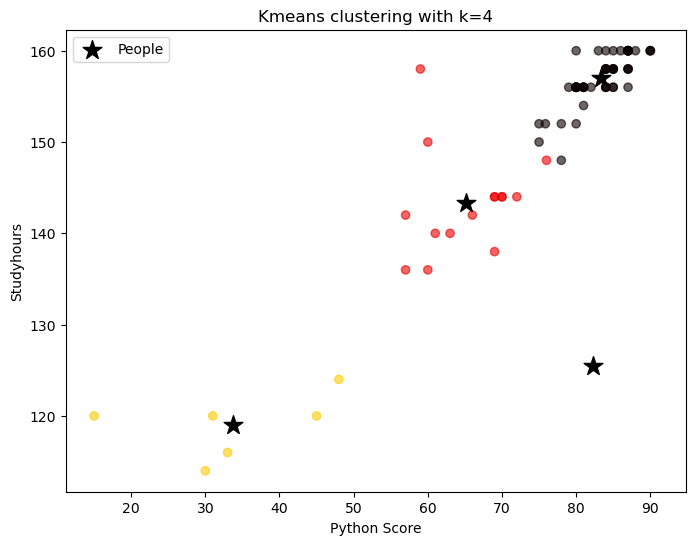

In [115]:
kmeans = KMeans(n_clusters = 4 , random_state = 0 , n_init = 10)
bi['cluster'] = kmeans.fit_predict(X_scaled)

plt.figure(figsize= (8,6))
plt.scatter(X['Python'], X['Studyhours'], c=bi["cluster"], cmap = "hot", alpha = 0.6)

centers = scaler.inverse_transform (kmeans.cluster_centers_)
plt.scatter(centers[:,0], centers[:,1], c= "black", marker="*", s=200 , label = "People")

plt.xlabel("Python Score")
plt.ylabel("Studyhours")
plt.title("Kmeans clustering with k=4")
plt.legend()
plt.show()

### 5. Explain why you chose this dataset and why k-means is appropriate.

I chose this dataset as I relate to it the most, it reflects on the categorical and numerical features of Age, Study Hours, Python Scores and Database Scores. Although another factor as to why I chose this dataset was because it was hard for me to find appropriate datasets which has missing values as all the provided datasets on kaggle has already been filled in, I found this dataset to be rather interesting and fun as I get to learn about new facts such as Norge is the Swedish name for Norway or like the elbow method approach to finding the best k value for clustering. K-means is appopriate for this because it helps to group those similar people who have similar traits and it only works for numerical data. Which after grouping, we can analyse better on individual clusters to see if it has a strong pattern, or whether two factors correlate to each other. For example, we can identify if students who study longer tends to do well in python or use this dataset to detect at risk students and consult them.

### 6. What patterns did you expect before clustering, and how do results compare with your expectations?

Generally, everybody wants to do well in Python (as do I), so I assume the general population might study mid to high range of hours and get decent to excelling marks in their python score, whereas there are some that might fall behind as they have lesser study hours, so generally I was expecting a cluster in the mid high ranges of both python scores and study hours and a small cluster in the lower range of both study hours and python score. After clustering, I can clearly see that I am somewhat correct, whereby there is two clusters in the mid range and high range of python scores, and there are those that tend to fall behind. But what surprised me is there exists a cluster at the most bottom right corner, depicting some students who have less study hours but still excel very well in Python. So in a way the results are somewhat difference from my expectations. 